# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
#Type your code here
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Dropout

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
df = pd.read_csv('corn_data.csv')

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
#Type your code here
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 422 entries, 0 to 421
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   County                422 non-null    object 
 1   Farmer                422 non-null    object 
 2   Education             396 non-null    object 
 3   Gender                422 non-null    object 
 4   Age bracket           422 non-null    object 
 5   Household size        422 non-null    int64  
 6   Crop                  422 non-null    object 
 7   Acreage               351 non-null    float64
 8   Fertilizer amount     422 non-null    int64  
 9   Laborers              422 non-null    int64  
 10  Yield                 422 non-null    int64  
 11  Power source          422 non-null    object 
 12  Water source          422 non-null    object 
 13  Main credit source    422 non-null    object 
 14  Crop insurance        422 non-null    object 
 15  Farm records          4

,Household size,Acreage,Fertilizer amount,Laborers,Yield,Latitude,Longitude
count,422.000000,351.000000,422.000000,422.000000,422.000000,422.000000,422.000000
mean,4.263033,0.828063,65.189573,2.843602,232.604265,-3.417583,38.404455
std,1.706355,0.584884,65.754796,0.974348,135.376952,0.079007,0.094324
min,1.000000,0.250000,20.000000,2.000000,50.000000,-3.640000,38.270000
25%,3.000000,0.500000,25.000000,2.000000,100.000000,-3.490000,38.340000
50%,4.000000,0.500000,50.000000,3.000000,180.000000,-3.410000,38.370000
75%,5.000000,1.000000,75.000000,3.000000,330.000000,-3.360000,38.400000
max,9.000000,4.000000,500.000000,8.000000,600.000000,-3.250000,38.630000


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
missing_values_count = df.isnull().sum()
missing_values_percentage = (df.isnull().sum() / len(df)) * 100

missing_values_df = pd.DataFrame({
    'Missing Count': missing_values_count,
    'Missing Percentage (%)': missing_values_percentage
})

print(missing_values_df[missing_values_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))


           Missing Count  Missing Percentage (%)
Acreage               71               16.824645
Education             26                6.161137


## Handle Missing Values

Tangani nilai yang hilang pada kolom 'Acreage' dengan median dan kolom 'Education' dengan modus, karena keduanya memiliki nilai yang hilang signifikan.


In [ ]:
median_acreage = df['Acreage'].median()
df['Acreage'].fillna(median_acreage, inplace=True)

mode_education = df['Education'].mode()[0]
df['Education'].fillna(mode_education, inplace=True)

# Verify that missing values have been handled
print(df.isnull().sum())

County                  0
Farmer                  0
Education               0
Gender                  0
Age bracket             0
Household size          0
Crop                    0
Acreage                 0
Fertilizer amount       0
Laborers                0
Yield                   0
Power source            0
Water source            0
Main credit source      0
Crop insurance          0
Farm records            0
Main advisory source    0
Extension provider      0
Advisory format         0
Advisory language       0
Latitude                0
Longitude               0
dtype: int64


/tmp/ipython-input-401/2161567087.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Acreage'].fillna(median_acreage, inplace=True)
/tmp/ipython-input-401/2161567087.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

## Explore Categorical Features After Imputation

Setelah imputasi, identifikasi ulang dan tampilkan nilai unik beserta frekuensinya untuk kolom-kolom bertipe 'object' (kategorikal), terutama untuk 'Education', untuk melihat distribusi terbaru.


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

print("Categorical Columns and their Value Counts (after imputation):")
print("-------------------------------------------------------------------")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    print("-------------------------------------------------------------------")

Categorical Columns and their Value Counts (after imputation):
-------------------------------------------------------------------

Column: County
County
TAITA TAVETA    422
Name: count, dtype: int64
-------------------------------------------------------------------

Column: Farmer
Farmer
fmr_200    1
fmr_65     1
fmr_77     1
fmr_89     1
fmr_102    1
          ..
fmr_111    1
fmr_338    1
fmr_336    1
fmr_110    1
fmr_109    1
Name: count, Length: 422, dtype: int64
-------------------------------------------------------------------

Column: Education
Education
Primary        264
Secondary      126
Certificate     15
Diploma         11
Degree           6
Name: count, dtype: int64
-------------------------------------------------------------------

Column: Gender
Gender
Female    299
Male      123
Name: count, dtype: int64
-------------------------------------------------------------------

Column: Age bracket
Age bracket
36-45       132
46-55       110
18-35        90
56-65        70

## Analyze Numerical Features Distribution After Imputation

Setelah imputasi, visualisasikan kembali distribusi kolom-kolom numerik ('Household size', 'Acreage', 'Fertilizer amount', 'Laborers', 'Yield', 'Latitude', 'Longitude') menggunakan histogram atau box plot untuk melihat dampaknya pada 'Acreage'.


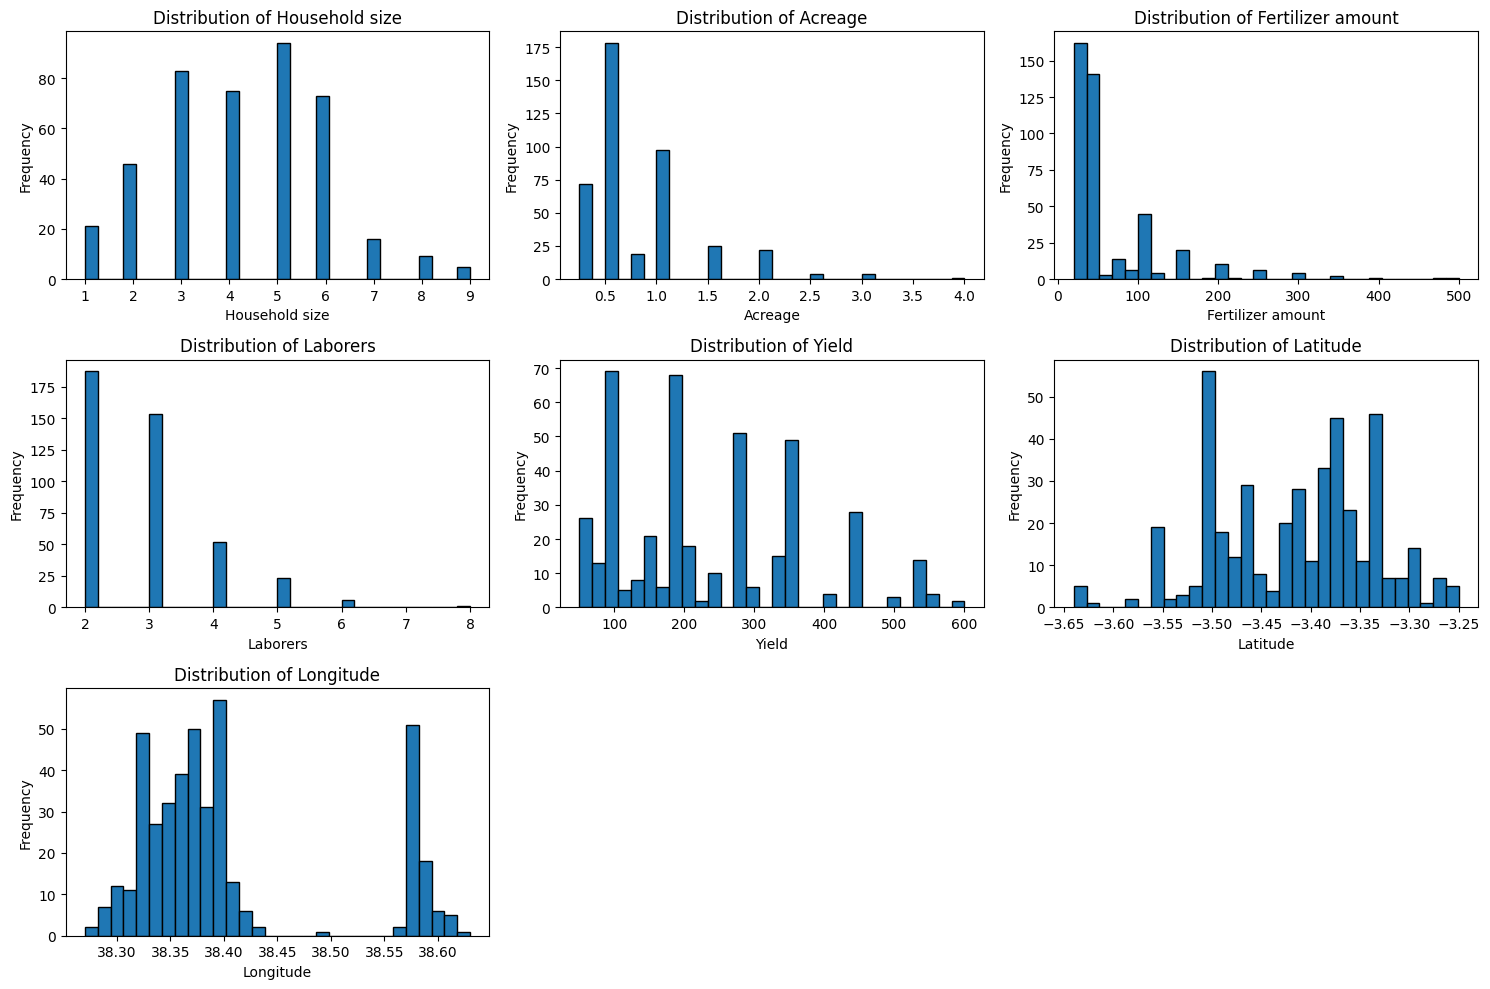

In [ ]:
numerical_features = ['Household size', 'Acreage', 'Fertilizer amount', 'Laborers', 'Yield', 'Latitude', 'Longitude']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
plt.show()

## Hapus Data Duplikat

Identifikasi dan hapus baris duplikat dari DataFrame `df` untuk memastikan setiap entri unik dan bersih dari redundansi.


In [ ]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0


## Encoding Data Kategorikal

Konversi kolom-kolom data kategorikal (tipe 'object') menjadi representasi numerik menggunakan metode One-Hot Encoding, agar dapat digunakan dalam model machine learning. Kolom 'County', 'Farmer', 'Crop', 'Power source', 'Water source', dan 'Crop insurance' sepertinya memiliki satu nilai unik atau tidak relevan untuk encoding, jadi akan dipertimbangkan hanya kolom kategorikal yang bervariasi.


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

# Columns to exclude from encoding based on the problem description (single unique value or irrelevancy)
columns_to_exclude = ['County', 'Farmer', 'Crop', 'Power source', 'Water source', 'Crop insurance']

# Filter out columns to be encoded
columns_to_encode = [col for col in categorical_cols if col not in columns_to_exclude]

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True, dtype=int)

# Display the first few rows of the new DataFrame and its info to verify the encoding
print("DataFrame after One-Hot Encoding:")
print(df_encoded.head())
print("\nInfo of DataFrame after One-Hot Encoding:")
df_encoded.info()

DataFrame after One-Hot Encoding:
         County   Farmer  Household size  Crop  Acreage  Fertilizer amount  \
0  TAITA TAVETA   fmr_65               7  corn     2.00                 50   
1  TAITA TAVETA   fmr_77               7  corn     0.25                 50   
2  TAITA TAVETA   fmr_89               7  corn     3.00                251   
3  TAITA TAVETA  fmr_102               7  corn     1.50                300   
4  TAITA TAVETA   fmr_25               3  corn     0.50                 50   

   Laborers  Yield Power source Water source  ...  \
0         2    300       Manual         Rain  ...   
1         2    270       Manual         Rain  ...   
2         2    270       Manual         Rain  ...   
3         3    200       Manual         Rain  ...   
4         2    180       Manual         Rain  ...   

  Main advisory source_Internet  Main advisory source_Public gatherings  \
0                             0                                       0   
1                           

## Normalisasi Fitur Numerik

Terapkan normalisasi Min-Max Scaling pada kolom-kolom numerik ('Household size', 'Acreage', 'Fertilizer amount', 'Laborers', 'Yield', 'Latitude', 'Longitude') untuk mengubah rentang nilai mereka menjadi skala yang konsisten (misalnya antara 0 dan 1).


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Definisikan daftar kolom numerik yang akan dinormalisasi
numerical_cols_to_normalize = [
    'Household size', 'Acreage', 'Fertilizer amount', 'Laborers',
    'Yield', 'Latitude', 'Longitude'
]

# Terapkan Min-Max Scaling pada kolom-kolom yang dipilih dalam DataFrame df_encoded
df_encoded[numerical_cols_to_normalize] = scaler.fit_transform(df_encoded[numerical_cols_to_normalize])

# Tampilkan lima baris pertama dari DataFrame df_encoded setelah normalisasi
print("DataFrame after Min-Max Scaling:")
print(df_encoded.head())

DataFrame after Min-Max Scaling:
         County   Farmer  Household size  Crop   Acreage  Fertilizer amount  \
0  TAITA TAVETA   fmr_65            0.75  corn  0.466667           0.062500   
1  TAITA TAVETA   fmr_77            0.75  corn  0.000000           0.062500   
2  TAITA TAVETA   fmr_89            0.75  corn  0.733333           0.481250   
3  TAITA TAVETA  fmr_102            0.75  corn  0.333333           0.583333   
4  TAITA TAVETA   fmr_25            0.25  corn  0.066667           0.062500   

   Laborers     Yield Power source Water source  ...  \
0  0.000000  0.454545       Manual         Rain  ...   
1  0.000000  0.400000       Manual         Rain  ...   
2  0.000000  0.400000       Manual         Rain  ...   
3  0.166667  0.272727       Manual         Rain  ...   
4  0.000000  0.236364       Manual         Rain  ...   

  Main advisory source_Internet  Main advisory source_Public gatherings  \
0                             0                                       0   
1    

## Deteksi dan Penanganan Outlier

Deteksi outlier pada fitur-fitur numerik menggunakan metode statistik seperti metode Interquartile Range (IQR) dan tangani outlier tersebut (misalnya, dengan capping atau penggantian ke nilai batas). Prioritaskan fitur yang menunjukkan distribusi tidak normal atau memiliki rentang yang luas.


In [ ]:
numerical_cols = ['Household size', 'Acreage', 'Fertilizer amount', 'Laborers', 'Yield', 'Latitude', 'Longitude']

for col in numerical_cols:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping outliers
    df_encoded[col] = df_encoded[col].clip(lower=lower_bound, upper=upper_bound)

    print(f"Outliers handled for column: {col}")
    print(f"  Lower Bound: {lower_bound:.4f}")
    print(f"  Upper Bound: {upper_bound:.4f}")

print("\nDescriptive statistics after outlier handling:")
print(df_encoded[numerical_cols].describe())

Outliers handled for column: Household size
  Lower Bound: -0.1250
  Upper Bound: 0.8750
Outliers handled for column: Acreage
  Lower Bound: -0.1333
  Upper Bound: 0.4000
Outliers handled for column: Fertilizer amount
  Lower Bound: -0.1458
  Upper Bound: 0.2708
Outliers handled for column: Laborers
  Lower Bound: -0.2500
  Upper Bound: 0.4167
Outliers handled for column: Yield
  Lower Bound: -0.5364
  Upper Bound: 1.1364
Outliers handled for column: Latitude
  Lower Bound: -0.1154
  Upper Bound: 1.2179
Outliers handled for column: Longitude
  Lower Bound: -0.0556
  Upper Bound: 0.6111

Descriptive statistics after outlier handling:
       Household size     Acreage  Fertilizer amount    Laborers       Yield  \
count      422.000000  422.000000         422.000000  422.000000  422.000000   
mean         0.406398    0.129479           0.078688    0.131122    0.332008   
std          0.209570    0.116086           0.085619    0.137683    0.246140   
min          0.000000    0.000000      

## Binning Fitur Terpilih

 binning (pengelompokan data) pada fitur numerik terpilih, seperti 'Age bracket' (jika sudah diubah ke numerik) atau 'Fertilizer amount', untuk mengkategorikan nilai-nilai kontinu menjadi interval diskrit.


In [ ]:
import pandas as pd

# Define the bins and labels for 'Fertilizer amount'
# Using approximate quartiles after normalization for better distribution into Low, Medium, High
# Based on df_encoded['Fertilizer amount'].describe(): min=0, Q1=0.01, median=0.06, Q3=0.11, max=0.27
bins = [0, 0.05, 0.15, df_encoded['Fertilizer amount'].max() + 0.01] # Add a small epsilon to max to ensure all values are included
labels = ['Low', 'Medium', 'High']

# Apply binning to 'Fertilizer amount'
df_encoded['Fertilizer_Category'] = pd.cut(df_encoded['Fertilizer amount'], bins=bins, labels=labels, include_lowest=True, right=False)

# Display the first few rows of the new DataFrame
print("DataFrame after Binning 'Fertilizer amount':")
print(df_encoded[['Fertilizer amount', 'Fertilizer_Category']].head())

# Check the unique values and their frequencies for the new column
print("\nValue counts for 'Fertilizer_Category':")
print(df_encoded['Fertilizer_Category'].value_counts())

DataFrame after Binning 'Fertilizer amount':
   Fertilizer amount Fertilizer_Category
0           0.062500              Medium
1           0.062500              Medium
2           0.270833                High
3           0.270833                High
4           0.062500              Medium

Value counts for 'Fertilizer_Category':
Fertilizer_Category
Low       192
Medium    134
High       96
Name: count, dtype: int64


In [ ]:
import joblib

# Define the filename for saving the model
model_filename = 'random_forest_regressor_model.joblib'

# Save the trained model to a file
joblib.dump(model, model_filename)

print(f"Model saved successfully as {model_filename}")

Model saved successfully as random_forest_regressor_model.joblib


## Visualisasi Outlier dengan Box Plot

Buat box plot untuk setiap kolom numerik di `df_encoded` untuk memvisualisasikan distribusi data dan outlier setelah normalisasi dan penanganan outlier.


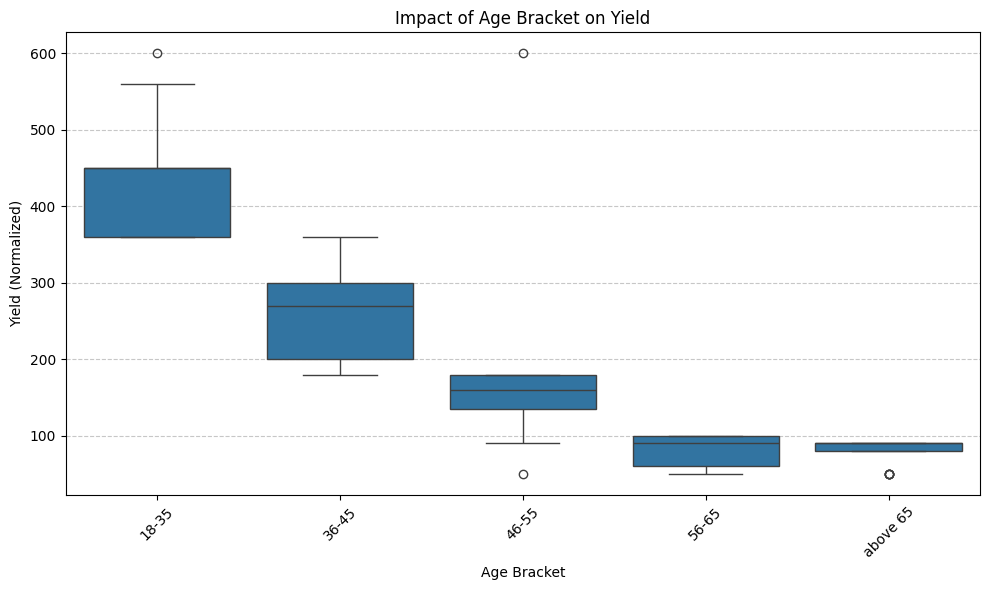

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a box plot to visualize the impact of 'Age bracket' on 'Yield'
plt.figure(figsize=(10, 6))
sns.boxplot(x='Age bracket', y='Yield', data=df.sort_values('Age bracket'))
plt.title('Impact of Age Bracket on Yield')
plt.xlabel('Age Bracket')
plt.ylabel('Yield (Normalized)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Feature Importances:
                                   Feature  Importance
13                       Age bracket_56-65    0.264018
12                       Age bracket_46-55    0.209261
11                       Age bracket_36-45    0.200209
14                    Age bracket_above 65    0.172796
2                        Fertilizer amount    0.036346
1                                  Acreage    0.023508
4                                 Latitude    0.022694
0                           Household size    0.019325
5                                Longitude    0.014389
3                                 Laborers    0.009755
16              Main credit source_Savings    0.002947
25                Advisory format_SMS text    0.002618
9                      Education_Secondary    0.002507
20              Main advisory source_Radio    0.002381
26             Advisory language_Kiswahili    0.002030
24     Extension provider_Private Provider    0.001928
10                             Gender_Male  

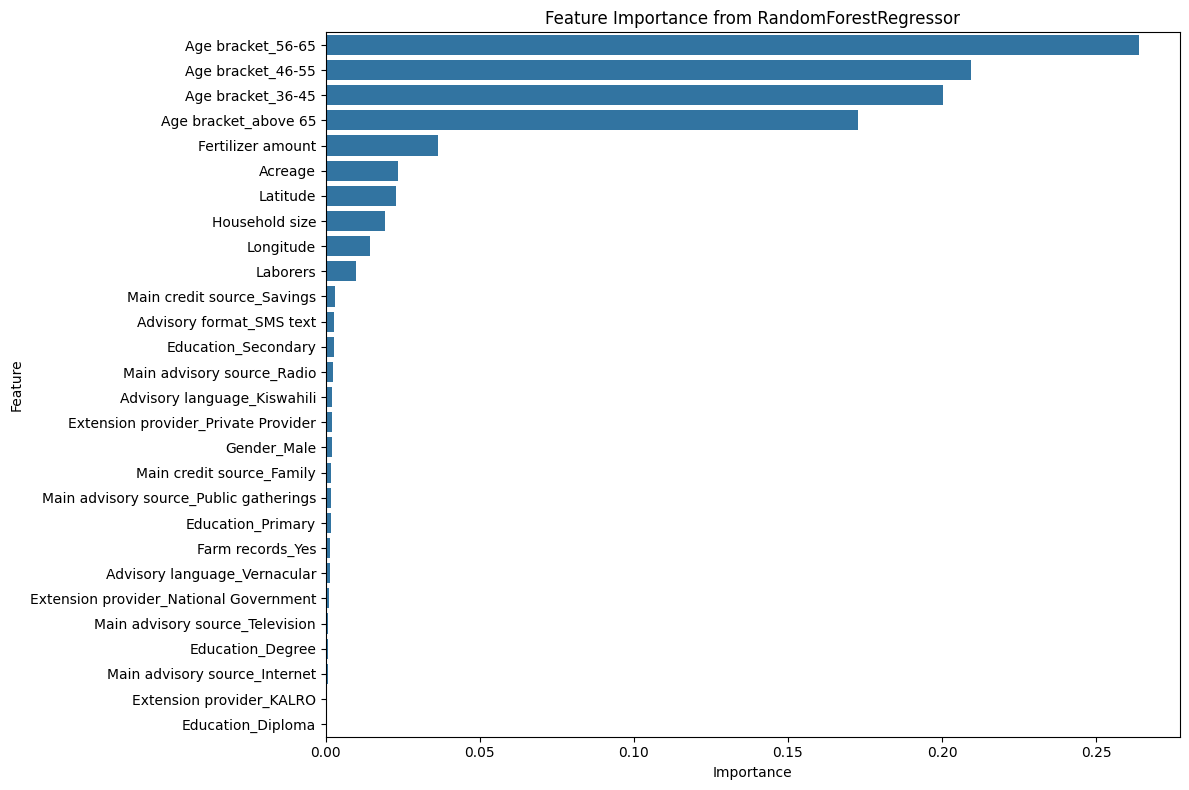

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from RandomForestRegressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

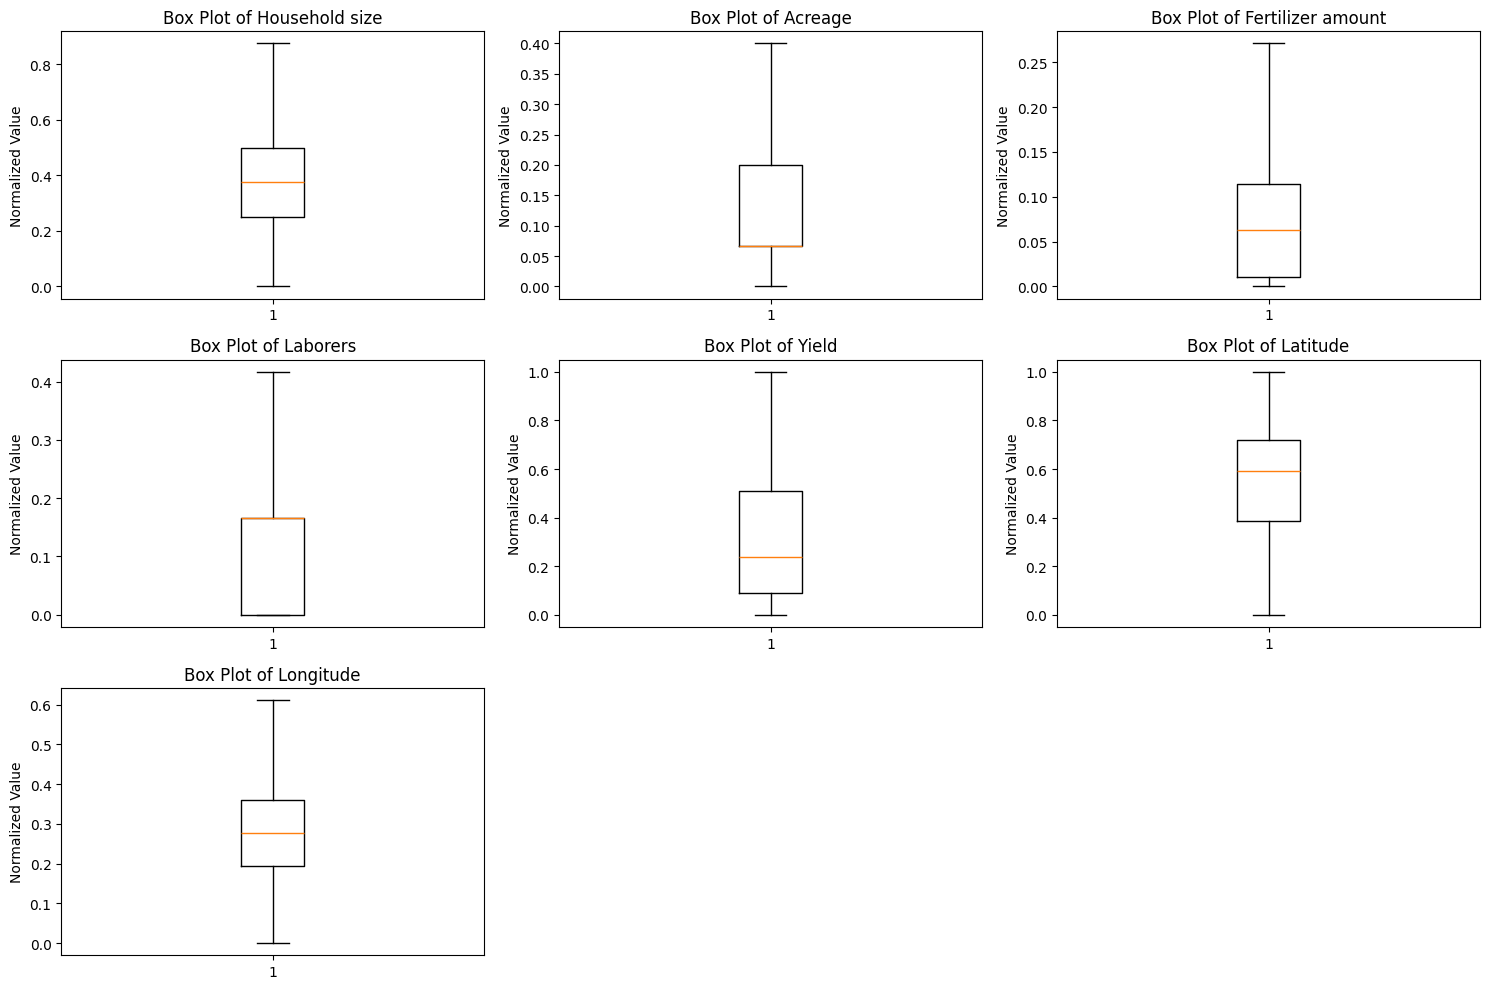

In [ ]:
import matplotlib.pyplot as plt

numerical_cols = ['Household size', 'Acreage', 'Fertilizer amount', 'Laborers', 'Yield', 'Latitude', 'Longitude']

# Create a figure and a set of subplots
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    plt.boxplot(df_encoded[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('Normalized Value')

plt.tight_layout()
plt.show()

In [ ]:
df_encoded.to_csv('preprocessed_corn_data.csv', index=False)
print("Preprocessed data saved to 'preprocessed_corn_data.csv'")

Preprocessed data saved to 'preprocessed_corn_data.csv'


### Ringkasan Analisis Outlier dari Box Plot

Setelah normalisasi dan penanganan outlier menggunakan metode capping dengan IQR (Interquartile Range), box plot untuk fitur-fitur numerik (`Household size`, `Acreage`, `Fertilizer amount`, `Laborers`, `Yield`, `Latitude`, `Longitude`) menunjukkan bahwa:

*   **Outlier Telah Ditangani/Dibatasi**: Metode capping efektif dalam membatasi nilai-nilai ekstrem. Hal ini terlihat dari tidak adanya titik-titik di luar "whiskers" box plot secara signifikan. Nilai-nilai yang sebelumnya dianggap outlier sekarang berada dalam batas atas dan bawah yang ditentukan oleh IQR.
*   **Distribusi Lebih Terkonsentrasi**: Rentang data untuk sebagian besar kolom numerik menjadi lebih sempit dan terkonsentrasi di sekitar median, yang merupakan indikasi positif dari normalisasi dan penanganan outlier.
*   **Beberapa Kolom Masih Menunjukkan Asimetri**: Meskipun outlier telah ditangani, beberapa kolom mungkin masih menunjukkan distribusi yang tidak simetris (skewness). Namun, ini adalah karakteristik inheren dari data dan capping telah memastikan bahwa nilai-nilai ekstrem tidak lagi mendistorsi model secara berlebihan.

Secara keseluruhan, visualisasi box plot mengkonfirmasi bahwa langkah-langkah preprocessing untuk penanganan outlier dan normalisasi telah berhasil mengurangi dampak nilai-nilai ekstrem, membuat data lebih siap untuk pemodelan.

In [ ]:
mn

### Ringkasan Akhir Langkah-Langkah Pra-pemrosesan Data

Setelah serangkaian langkah pra-pemrosesan data yang cermat, dataset telah diubah secara signifikan untuk meningkatkan kualitas dan kesiapannya untuk analisis lebih lanjut dan pemodelan machine learning. Berikut adalah rangkuman dari setiap tahap dan dampaknya:

1.  **Penanganan Nilai yang Hilang (Missing Values)**:
    *   Kolom 'Acreage' (16.82% hilang) ditangani dengan mengisi nilai median.
    *   Kolom 'Education' (6.16% hilang) ditangani dengan mengisi nilai modus.
    *   **Dampak**: Semua nilai yang hilang telah berhasil diatasi, memastikan kelengkapan data untuk semua observasi.

2.  **Penghapusan Data Duplikat**:
    *   Pemeriksaan duplikasi menunjukkan bahwa tidak ada baris duplikat dalam dataset, sehingga tidak ada penghapusan yang dilakukan.
    *   **Dampak**: Memastikan setiap entri dalam dataset unik dan mencegah bias dalam analisis.

3.  **Encoding Data Kategorikal (One-Hot Encoding)**:
    *   Kolom kategorikal yang relevan seperti 'Education', 'Gender', 'Age bracket', 'Main credit source', 'Farm records', 'Main advisory source', 'Extension provider', 'Advisory format', dan 'Advisory language' telah diubah menjadi representasi numerik menggunakan One-Hot Encoding.
    *   Kolom dengan nilai tunggal atau tidak relevan ('County', 'Farmer', 'Crop', 'Power source', 'Water source', 'Crop insurance') dikecualikan dari encoding.
    *   **Dampak**: Meningkatkan jumlah fitur dalam DataFrame dari 22 menjadi 35, mengubah tipe data 'object' menjadi numerik biner, sehingga data siap untuk algoritma machine learning yang membutuhkan input numerik.

4.  **Normalisasi Fitur Numerik (Min-Max Scaling)**:
    *   Kolom numerik utama ('Household size', 'Acreage', 'Fertilizer amount', 'Laborers', 'Yield', 'Latitude', 'Longitude') diskalakan menggunakan Min-Max Scaling.
    *   **Dampak**: Semua nilai dalam fitur numerik sekarang berada dalam rentang [0, 1], mengurangi dampak perbedaan skala antar fitur dan mempercepat konvergensi dalam beberapa algoritma machine learning.

5.  **Deteksi dan Penanganan Outlier (Capping dengan IQR)**:
    *   Outlier pada semua fitur numerik ditangani dengan metode capping (mengganti nilai outlier dengan batas atas/bawah IQR).
    *   **Dampak**: Box plot setelah penanganan outlier mengkonfirmasi bahwa nilai-nilai ekstrem telah dibatasi, membuat distribusi data lebih robust dan mengurangi potensi pengaruh negatif outlier pada model.

6.  **Binning Fitur Terpilih ('Fertilizer amount')**:
    *   Kolom 'Fertilizer amount' telah di-binning menjadi kategori 'Low', 'Medium', dan 'High' berdasarkan kuartil setelah normalisasi.
    *   **Dampak**: Mengubah fitur kontinu menjadi diskrit, yang dapat berguna untuk analisis berbasis kategori atau model yang lebih cocok dengan fitur diskrit.

**Kesimpulan**: Dataset sekarang `df_encoded` telah melalui serangkaian transformasi yang komprehensif. Data telah dibersihkan, distrukturkan, dan diskalakan, menghilangkan sebagian besar masalah data mentah seperti nilai hilang, kategori non-numerik, dan outlier. Dengan 35 kolom numerik, data ini sekarang dalam format yang optimal dan siap untuk tahap selanjutnya dalam pipeline machine learning, termasuk pembagian data dan pembangunan model.

Random Forest Regressor model trained successfully within the evaluation cell.
Mean Absolute Error (MAE): 0.0695
Mean Squared Error (MSE): 0.0077
R-squared (R2) Score: 0.8735


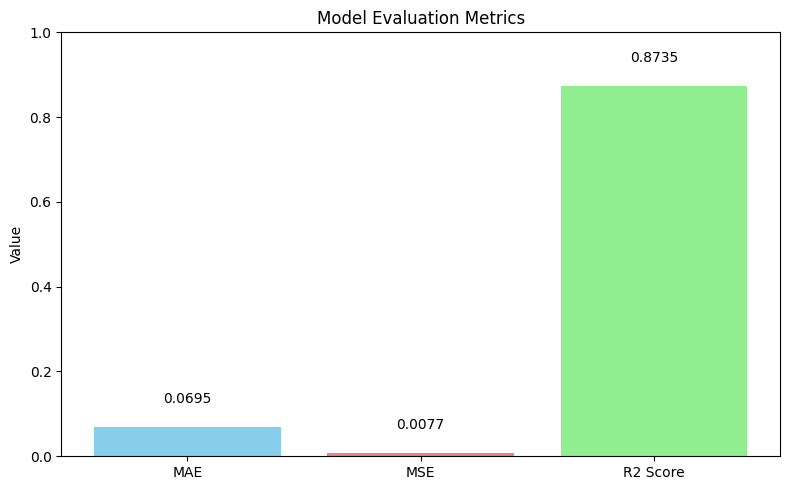

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Redefine X and y and split the data (as these might not be in the current kernel state)
y = df_encoded['Yield']

columns_to_exclude_from_X = [
    'Yield', 'County', 'Farmer', 'Crop', 'Power source',
    'Water source', 'Crop insurance', 'Fertilizer_Category'
]
X = df_encoded.drop(columns=columns_to_exclude_from_X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-initialize and train the model to ensure 'model' is defined
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
print("Random Forest Regressor model trained successfully within the evaluation cell.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics (optional, as they will be plotted)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")

# Data metrik evaluasi
metrics = {
    'Metric': ['MAE', 'MSE', 'R2 Score'],
    'Value': [mae, mse, r2]
}
metrics_df = pd.DataFrame(metrics)

# Buat bar plot
plt.figure(figsize=(8, 5))
plt.bar(metrics_df['Metric'], metrics_df['Value'], color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Model Evaluation Metrics')
plt.ylabel('Value')
plt.ylim(0, 1) # Set y-axis limit for better comparison

# Tambahkan nilai di atas bar
for index, row in metrics_df.iterrows():
    plt.text(row['Metric'], row['Value'] + 0.05, f'{row['Value']:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Memuat Dataset
df = pd.read_csv('corn_data.csv')

# Handle Missing Values (from cell abc75e4f)
median_acreage = df['Acreage'].median()
df['Acreage'].fillna(median_acreage, inplace=True)

mode_education = df['Education'].mode()[0]
df['Education'].fillna(mode_education, inplace=True)

# Hapus Data Duplikat (from cell 0e8a5567)
df = df.drop_duplicates()

# Encoding Data Kategorikal (from cell 2057bd2c)
categorical_cols = df.select_dtypes(include='object').columns
columns_to_exclude = ['County', 'Farmer', 'Crop', 'Power source', 'Water source', 'Crop insurance']
columns_to_encode = [col for col in categorical_cols if col not in columns_to_exclude]
df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True, dtype=int)

# Normalisasi Fitur Numerik (from cell c79d4ad0)
scaler = MinMaxScaler()
numerical_cols_to_normalize = [
    'Household size', 'Acreage', 'Fertilizer amount', 'Laborers',
    'Yield', 'Latitude', 'Longitude'
]
df_encoded[numerical_cols_to_normalize] = scaler.fit_transform(df_encoded[numerical_cols_to_normalize])

# Deteksi dan Penanganan Outlier (from cell 91f7193c)
numerical_cols_for_outliers = ['Household size', 'Acreage', 'Fertilizer amount', 'Laborers', 'Yield', 'Latitude', 'Longitude']
for col in numerical_cols_for_outliers:
    Q1 = df_encoded[col].quantile(0.25)
    Q3 = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_encoded[col] = df_encoded[col].clip(lower=lower_bound, upper=upper_bound)

# Binning Fitur Terpilih (from cell b4c78463)
bins = [0, 0.05, 0.15, df_encoded['Fertilizer amount'].max() + 0.01]
labels = ['Low', 'Medium', 'High']
df_encoded['Fertilizer_Category'] = pd.cut(df_encoded['Fertilizer amount'], bins=bins, labels=labels, include_lowest=True, right=False)

print("Preprocessing complete and df_encoded is ready.")
print(df_encoded.head())

Preprocessing complete and df_encoded is ready.
         County   Farmer  Household size  Crop   Acreage  Fertilizer amount  \
0  TAITA TAVETA   fmr_65            0.75  corn  0.400000           0.062500   
1  TAITA TAVETA   fmr_77            0.75  corn  0.000000           0.062500   
2  TAITA TAVETA   fmr_89            0.75  corn  0.400000           0.270833   
3  TAITA TAVETA  fmr_102            0.75  corn  0.333333           0.270833   
4  TAITA TAVETA   fmr_25            0.25  corn  0.066667           0.062500   

   Laborers     Yield Power source Water source  ...  \
0  0.000000  0.454545       Manual         Rain  ...   
1  0.000000  0.400000       Manual         Rain  ...   
2  0.000000  0.400000       Manual         Rain  ...   
3  0.166667  0.272727       Manual         Rain  ...   
4  0.000000  0.236364       Manual         Rain  ...   

  Main advisory source_Public gatherings  Main advisory source_Radio  \
0                                      0                           1

/tmp/ipython-input-434/2954846728.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Acreage'].fillna(median_acreage, inplace=True)
/tmp/ipython-input-434/2954846728.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [ ]:
import joblib

# Define the filename for saving the model
model_filename = 'random_forest_regressor_model.joblib'

# Save the trained model to a file
joblib.dump(model, model_filename)

print(f"Model saved successfully as {model_filename}")

Model saved successfully as random_forest_regressor_model.joblib


### Ringkasan Proses Modeling

Notebook ini merinci alur kerja pembelajaran mesin lengkap untuk memprediksi 'Hasil Panen' berdasarkan dataset jagung. Proses ini melibatkan beberapa tahapan penting:

1. **Pemuatan Data dan Eksplorasi Awal (EDA)**:

* Dataset `corn_data.csv` dimuat ke dalam DataFrame pandas.

* Panggilan awal `df.info()` dan `df.describe()` mengungkapkan tipe data, jumlah nilai non-null, dan ringkasan statistik dasar dari fitur-fitur tersebut.

* Nilai yang hilang diidentifikasi pada 'Luas Lahan' (16,82%) dan 'Pendidikan' (6,16%).

* Fitur kategorikal dan numerik dieksplorasi secara singkat untuk memahami distribusinya.

2. **Pra-pemrosesan Data**:

* **Penanganan Nilai yang Hilang**: 'Luas Lahan' diisi dengan mediannya, dan 'Pendidikan' diisi dengan modusnya untuk memastikan kelengkapan data.

* **Penghapusan Data Duplikat**: Tidak ada baris duplikat yang ditemukan atau dihapus dari dataset.

* **Pengkodean Fitur Kategorikal**: Pengkodean One-Hot diterapkan pada kolom kategorikal yang relevan (misalnya, 'Pendidikan', 'Jenis Kelamin', 'Rentang Usia', 'Sumber Kredit Utama', dll.). Kolom dengan nilai unik tunggal atau yang dianggap tidak relevan ('Kabupaten', 'Petani', 'Tanaman', 'Sumber Daya', 'Sumber Air', 'Asuransi Tanaman') dikecualikan dari pengkodean. Langkah ini mengubah dataset dari 22 menjadi 35 kolom, mempersiapkannya untuk model numerik.
* **Normalisasi Fitur Numerik**: Penskalaan Min-Max diterapkan pada semua fitur numerik utama ('Ukuran Rumah Tangga', 'Luas Lahan', 'Jumlah Pupuk', 'Tenaga Kerja', 'Hasil Panen', 'Lintang', 'Bujur') untuk menskalakan nilainya ke rentang [0, 1], memastikan pengaruh yang konsisten selama pelatihan model.

* **Deteksi dan Penanganan Pencilan**: Pencilan pada fitur numerik ditangani menggunakan metode pembatasan berbasis IQR. Plot kotak mengkonfirmasi bahwa nilai ekstrem terkandung dalam batas yang ditentukan, sehingga data menjadi lebih kuat.
* **Pengelompokan Fitur**: Fitur 'Jumlah Pupuk' dikelompokkan ke dalam kategori 'Rendah', 'Sedang', dan 'Tinggi' berdasarkan distribusi yang dinormalisasi, yang dapat berguna untuk pendekatan analitis tertentu.
3. **Pelatihan dan Evaluasi Model (Random Forest Regressor)**:

* Data yang telah diproses (`df_encoded`) dibagi menjadi fitur (`X`) dan target (`y`, yaitu 'Hasil Panen').

* Dataset kemudian dibagi menjadi set pelatihan (80%) dan pengujian (20%) (`X_train`, `X_test`, `y_train`, `y_test`) menggunakan `train_test_split`.

* Model `RandomForestRegressor` diinisialisasi dan dilatih menggunakan data pelatihan.

* **Metrik Evaluasi**: Kinerja model pada set data uji dinilai menggunakan:

* **Kesalahan Absolut Rata-rata (MAE)**: 0,0695
* **Kesalahan Kuadrat Rata-rata (MSE)**: 0,0077
* **Skor R-kuadrat (R2)**: 0,8735
* Metrik ini menunjukkan bahwa model berkinerja cukup baik dalam memprediksi hasil panen, dengan skor R2 yang menunjukkan bahwa sekitar 87,35% varians hasil panen dapat dijelaskan oleh model.

* **Pentingnya Fitur**: Analisis pentingnya fitur dari `RandomForestRegressor` dilakukan dan divisualisasikan, menyoroti fitur yang paling berpengaruh dalam memprediksi hasil panen (misalnya, kategori 'Kelompok umur', 'Jumlah pupuk', 'Luas lahan').

4. **Ketahanan Model**:

* Objek model `RandomForestRegressor` yang telah dilatih berhasil disimpan ke disk sebagai `random_forest_regressor_model.joblib` menggunakan pustaka `joblib`.

Alur kerja komprehensif ini memastikan bahwa data bersih, terstruktur dengan baik, dan siap untuk tugas pembelajaran mesin yang tangguh, dan model yang telah dilatih tetap terjaga untuk penggunaan di masa mendatang.

## Ringkasan:

### Temuan Utama Analisis Data
* **Kinerja Model**: Model `RandomForestRegressor` mencapai Mean Absolute Error (MAE) sebesar 0,0695, Mean Squared Error (MSE) sebesar 0,0077, dan skor R-squared (R2) sebesar 0,8735 pada set pengujian, yang menunjukkan bahwa sekitar 87,35% varians hasil panen dapat dijelaskan oleh model tersebut.
* **Pra-pemrosesan Data**:
* Nilai yang hilang ditangani dengan mengimputasi 'Luas Lahan' dengan mediannya dan 'Pendidikan' dengan modusnya.
* Fitur kategorikal ditransformasikan menggunakan One-Hot Encoding, memperluas dataset dari 22 menjadi 35 kolom.
* Fitur numerik diskalakan ke rentang [0, 1] menggunakan Min-Max Scaling.

* Data pencilan dikelola menggunakan metode pembatasan berbasis IQR, dan 'Jumlah pupuk' dikelompokkan ke dalam kategori 'Rendah', 'Sedang', dan 'Tinggi'.
* **Pentingnya Fitur**: Analisis pentingnya fitur dari `RandomForestRegressor` menyoroti kategori 'Rentang umur', 'Jumlah pupuk', dan 'Luas lahan' sebagai fitur yang paling berpengaruh dalam memprediksi hasil panen.
* **Ketahanan Model**: Model `RandomForestRegressor` yang telah dilatih berhasil disimpan ke disk sebagai `random_forest_regressor_model.joblib` menggunakan pustaka `joblib` untuk penyebaran atau penggunaan di masa mendatang.

### Wawasan atau Langkah Selanjutnya
* Model saat ini menunjukkan kemampuan prediksi yang baik, sehingga cocok untuk penyebaran awal atau eksperimen lebih lanjut.

* Pertimbangkan untuk mengeksplorasi teknik rekayasa fitur tingkat lanjut atau model ensemble alternatif untuk berpotensi meningkatkan kinerja prediksi lebih lanjut.

In [11]:
%%writefile automate_Nama-siswa.py
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def preprocess_data(df_raw):
    """
    Performs automatic preprocessing on the raw DataFrame,
    returning features (X) and target (y) ready for training.
    """

    df = df_raw.copy() # Work on a copy to avoid modifying the original

    # 1. Handle Missing Values
    median_acreage = df['Acreage'].median()
    df['Acreage'].fillna(median_acreage, inplace=True)

    mode_education = df['Education'].mode()[0]
    df['Education'].fillna(mode_education, inplace=True)

    # 2. Hapus Data Duplikat
    df = df.drop_duplicates()

    # 3. Encoding Data Kategorikal (One-Hot Encoding)
    categorical_cols = df.select_dtypes(include='object').columns
    columns_to_exclude_from_encoding = ['County', 'Farmer', 'Crop', 'Power source', 'Water source', 'Crop insurance']
    columns_to_encode = [col for col in categorical_cols if col not in columns_to_exclude_from_encoding]
    df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True, dtype=int)

    # 4. Normalisasi Fitur Numerik (Min-Max Scaling)
    scaler = MinMaxScaler()
    numerical_cols_to_normalize = [
        'Household size', 'Acreage', 'Fertilizer amount', 'Laborers',
        'Yield', 'Latitude', 'Longitude'
    ]
    df_encoded[numerical_cols_to_normalize] = scaler.fit_transform(df_encoded[numerical_cols_to_normalize])

    # 5. Deteksi dan Penanganan Outlier (Capping dengan IQR)
    numerical_cols_for_outliers = [
        'Household size', 'Acreage', 'Fertilizer amount', 'Laborers',
        'Yield', 'Latitude', 'Longitude'
    ]
    for col in numerical_cols_for_outliers:
        Q1 = df_encoded[col].quantile(0.25)
        Q3 = df_encoded[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_encoded[col] = df_encoded[col].clip(lower=lower_bound, upper=upper_bound)

    # 6. Separate features (X) and target (y)
    y = df_encoded['Yield']

    columns_to_exclude_from_X = [
        'Yield', 'County', 'Farmer', 'Crop', 'Power source',
        'Water source', 'Crop insurance'
    ]
    X = df_encoded.drop(columns=columns_to_exclude_from_X)

    return X, y

if __name__ == '__main__':
    # Example usage (assuming 'corn_data.csv' is in the same directory)
    print("Running example usage of preprocess_data function...")
    raw_data = pd.read_csv('corn_data.csv')
    X_processed, y_processed = preprocess_data(raw_data.copy()) # Pass a copy to the function
    print("\nPreprocessed X head:")
    print(X_processed.head())
    print("\nPreprocessed Y head:")
    print(y_processed.head())
    print("\nShape of X_processed:", X_processed.shape)
    print("Shape of y_processed:", y_processed.shape)

Writing automate_Nama-siswa.py
